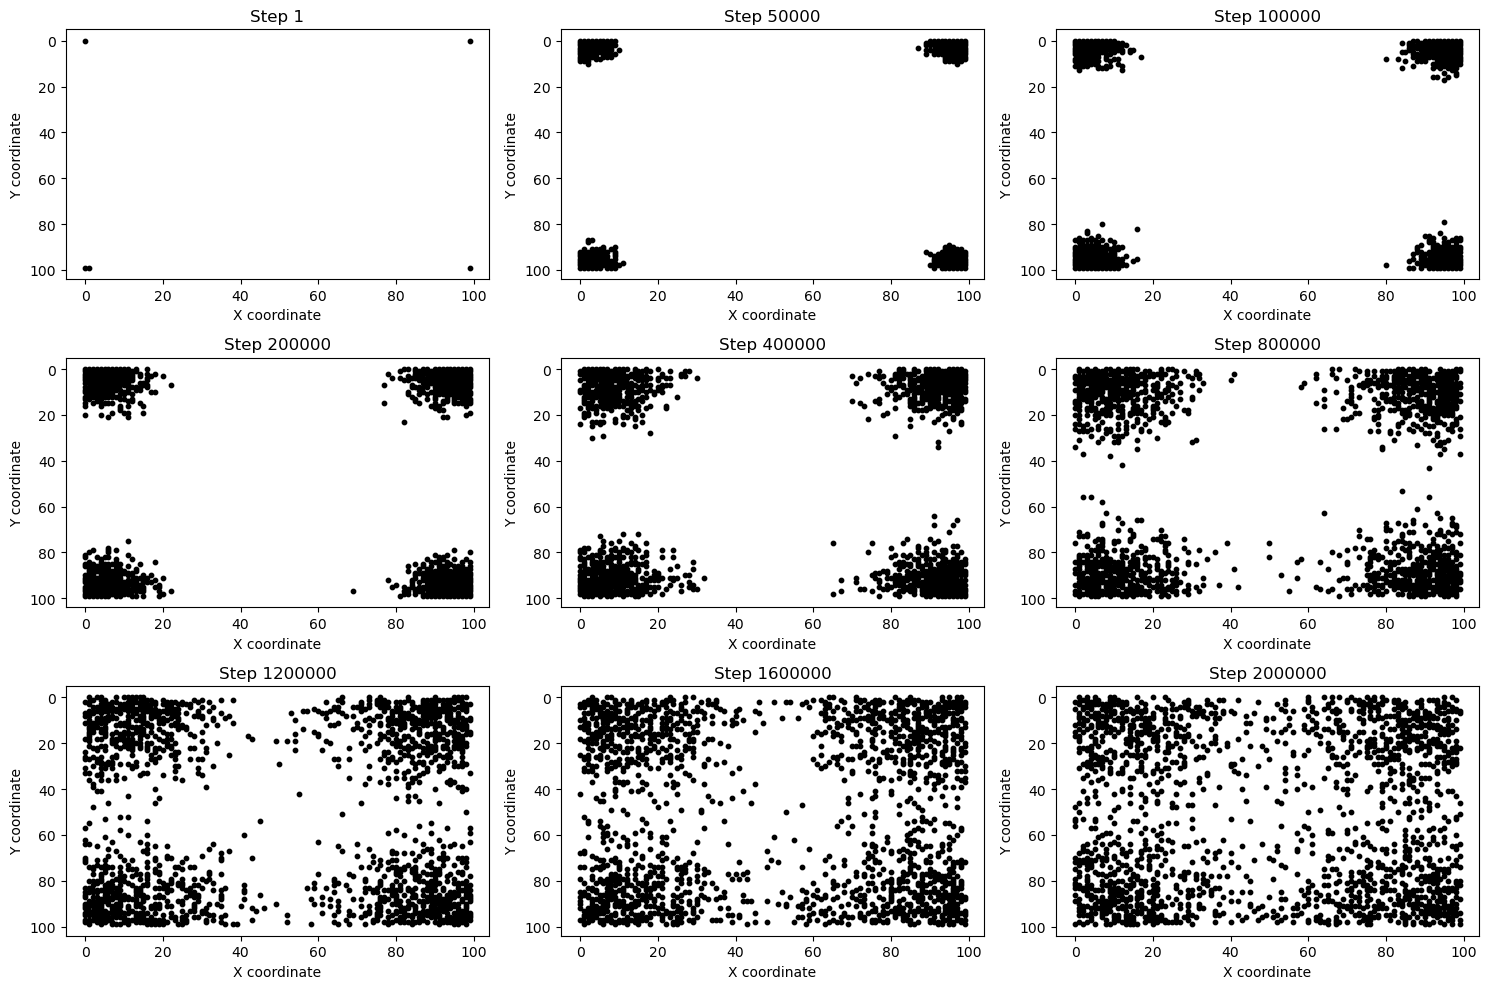

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# List of snapshot steps (t=0 removed) and corresponding filenames
snapshot_steps = [1, 50000, 100000, 200000, 400000, 800000, 1200000, 1600000, 2000000]
filenames = [f"snapshot_{step}.csv" for step in snapshot_steps]

# Create a 2x3 grid of subplots (one subplot may be unused)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

# Loop over each snapshot and plot only a dot for each grid cell that has any particles
for ax, step, filename in zip(axes, snapshot_steps, filenames):
    # Load CSV data (each cell holds the particle count)
    data = np.loadtxt(filename, delimiter=",")
    
    # Find indices where the count is greater than 0
    # y_indices are row numbers, x_indices are column numbers
    y_indices, x_indices = np.nonzero(data)
    
    # Plot a dot at each cell that has a nonzero count.
    # Here, s=10 sets the marker size and c='k' makes them black.
    ax.scatter(x_indices, y_indices, s=10, c='k', marker='o')
    
    # Optionally, invert the y-axis to mimic image coordinates (row 0 at the top)
    ax.invert_yaxis()
    
    ax.set_title(f"Step {step}")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")

# Hide any unused subplots (if there are more subplots than snapshots)
if len(snapshot_steps) < len(axes):
    for ax in axes[len(snapshot_steps):]:
        ax.set_visible(False)

plt.tight_layout()
plt.show()


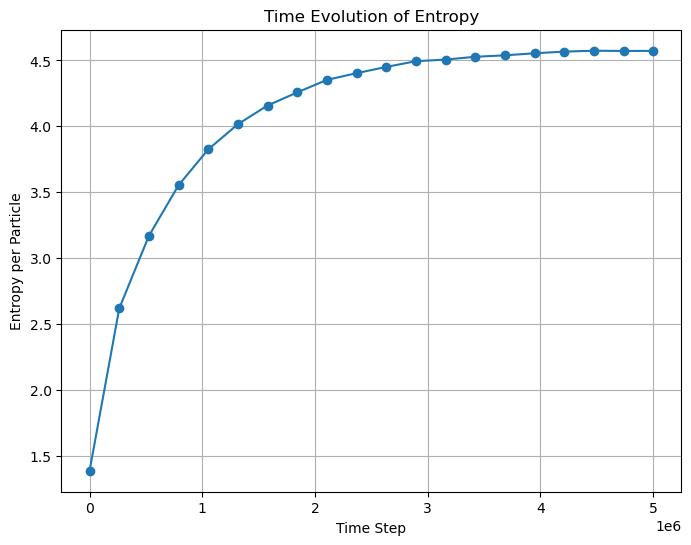

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV data (skip the header)
data = np.loadtxt("entropy_vs_time.csv", delimiter=",", skiprows=1)

time = data[:, 0]
entropy = data[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(time, entropy, marker='o')
plt.xlabel("Time Step")
plt.ylabel("Entropy per Particle")
plt.title("Time Evolution of Entropy")
plt.grid(True)
plt.show()


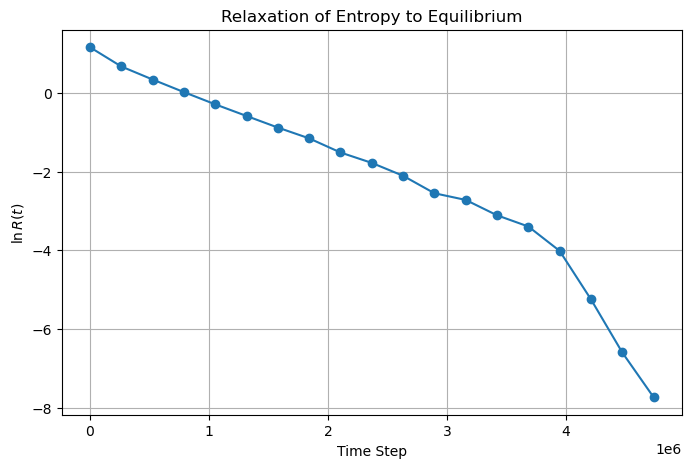

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load entropy data (skip header)
data = np.loadtxt("entropy_vs_time.csv", delimiter=",", skiprows=1)
t = data[:, 0]
S = data[:, 1]

# Compute S(infinity) as the last value (or max of S)
S_inf = S[-1]  # You can also use S.max() if you prefer
R = np.abs(S - S_inf)

# Prevent log(0) by excluding zero values
valid = R > 0
t_valid = t[valid]
logR = np.log(R[valid])

# Plot log(R) vs. time
plt.figure(figsize=(8, 5))
plt.plot(t_valid, logR, 'o-')
plt.xlabel("Time Step")
plt.ylabel(r"$\ln R(t)$")
plt.title("Relaxation of Entropy to Equilibrium")
plt.grid(True)
plt.show()


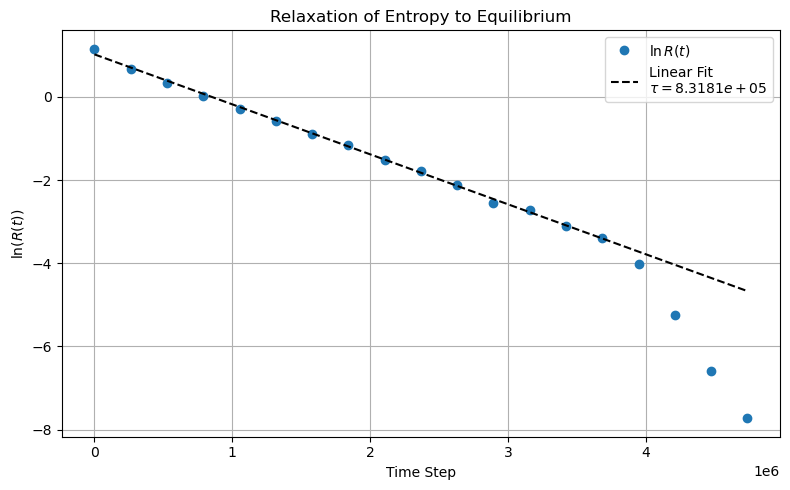

Slope: -1.2022e-06
Intercept: 1.0252
Estimated relaxation time τ ≈ 8.3181e+05


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Load entropy data
data = np.loadtxt("entropy_vs_time.csv", delimiter=",", skiprows=1)
t = data[:, 0]
S = data[:, 1]

# Calculate S_inf (final entropy) and R(t)
S_inf = S[-1]
R = np.abs(S - S_inf)

# Filter to exclude R=0 values (which would crash log)
valid = R > 0
t_valid = t[valid]
logR = np.log(R[valid])

# ----- Fit only the linear region -----
# Manually select the range to fit (e.g., midpoints ~ index 5 to 14)
i1, i2 = 5, 14  # adjust these indices based on your actual plot
t_fit = t_valid[i1:i2]
logR_fit = logR[i1:i2]

# Perform linear regression on the selected region
coeffs = np.polyfit(t_fit, logR_fit, 1)
slope, intercept = coeffs
tau = -1 / slope

# Generate fitted line over the full t range for plotting
t_line = np.linspace(t_valid[0], t_valid[-1], 500)
logR_line = slope * t_line + intercept

# ----- Plotting -----
plt.figure(figsize=(8, 5))
plt.plot(t_valid, logR, 'o', label=r"$\ln R(t)$")
plt.plot(t_line, logR_line, 'k--', label=f"Linear Fit\n$\\tau = {tau:.4e}$")
plt.xlabel("Time Step")
plt.ylabel(r"$\ln( R(t))$")
plt.title("Relaxation of Entropy to Equilibrium")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print results
print(f"Slope: {slope:.4e}")
print(f"Intercept: {intercept:.4f}")
print(f"Estimated relaxation time τ ≈ {tau:.4e}")


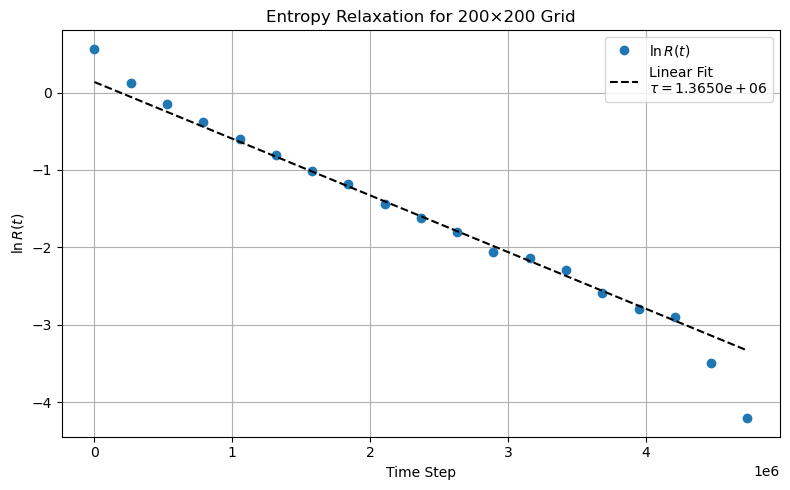

Slope: -7.3257e-07
Intercept: 0.1369
Estimated relaxation time τ ≈ 1.3650e+06


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Load the entropy vs. time data for the 200x200 grid
data = np.loadtxt("entropy_vs_time_L200.csv", delimiter=",", skiprows=1)
t = data[:, 0]
S = data[:, 1]

# Define S_inf as the final entropy (or use S.max() if preferred)
S_inf = S[-1]

# Compute the relaxation function: R(t) = |S(t) - S_inf|
R = np.abs(S - S_inf)

# Filter out any zeros (to avoid log(0))
valid = R > 0
t_valid = t[valid]
logR = np.log(R[valid])

# ----- Fit a linear region in the log(R) vs. t plot -----
# Manually select indices corresponding to the linear region (adjust these as needed)
i1, i2 = 5, 15  # For example, select indices 5 to 15 in the valid data
t_fit = t_valid[i1:i2]
logR_fit = logR[i1:i2]

# Perform linear regression on the selected region
coeffs = np.polyfit(t_fit, logR_fit, 1)
slope, intercept = coeffs
tau = -1 / slope  # Since slope = -1/tau

# Generate the fitted line over the range of the valid t data
t_line = np.linspace(t_valid[0], t_valid[-1], 500)
logR_line = slope * t_line + intercept

# ----- Plotting the data and the linear fit -----
plt.figure(figsize=(8, 5))
plt.plot(t_valid, logR, 'o', label=r"$\ln R(t)$")
plt.plot(t_line, logR_line, 'k--', label=f"Linear Fit\n$\\tau = {tau:.4e}$")
plt.xlabel("Time Step")
plt.ylabel(r"$\ln R(t)$")
plt.title("Entropy Relaxation for 200×200 Grid")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print out the fit parameters
print(f"Slope: {slope:.4e}")
print(f"Intercept: {intercept:.4f}")
print(f"Estimated relaxation time τ ≈ {tau:.4e}")
